In [44]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import math

## Importing data 

In [45]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jessemostipak/hotel-booking-demand")
# printing the file path
print("Path to dataset files:", path )
# Listing file in that directory to confirm the exact file name 
files = os.listdir(path)
print(f"Files in directory: {files}")

Path to dataset files: /kaggle/input/datasets/jessemostipak/hotel-booking-demand
Files in directory: ['hotel_bookings.csv']


In [46]:
# File name = ['hotel_bookings.csv']
csv_file_path=os.path.join(path,'hotel_bookings.csv')
# loading the file in dataframe 

df=pd.read_csv(csv_file_path)

# showing first 5 dataset
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


## Data Cleaning:


In [47]:
# Agent
missing_data=df.isnull().sum()
print("missing_data : \n",missing_data[missing_data>0])

# Count duplicates rows 
duplicates=df.duplicated().sum()
print(f"\n Total Duplicates : {duplicates}")

missing_data : 
 children         4
country        488
agent        16340
company     112593
dtype: int64

 Total Duplicates : 31994


In [48]:
# Removing Duplicated rows 
df=df.drop_duplicates()

#Handling missing Value by filling them with 0
df["children"]=df["children"].fillna(0)
df["agent"]=df["agent"].fillna(0)
df["company"]=df["agent"].fillna(0)

 # country with unknown
df["country"]=df["country"].fillna("Unknown")
# Verifying if the cleaning was successful 
print(f"Null values remaining : {df.isnull().sum()}")
print(f"Duplcated values Remaining :{df.duplicated().sum()}")

Null values remaining : hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
company                           0
days_in_waiting_list              0
customer_type                     0
adr 

> Convert date columns to appropriate datetime formats 

In [49]:
# converting the month string (e.g july) to numerical month
temp_date=pd.DataFrame({
    "year":  df["arrival_date_year"],
    "month": pd.to_datetime(df["arrival_date_month"],format="%B").dt.month,
    "day"  : df["arrival_date_day_of_month"]
        
    })

# Creating th new datetime column
df["arrival_date"]=pd.to_datetime(temp_date)

#checking new date df 
print(df[['arrival_date_year',
       'arrival_date_month',
       'arrival_date_day_of_month',"arrival_date"]].head())

   arrival_date_year arrival_date_month  arrival_date_day_of_month  \
0               2015               July                          1   
1               2015               July                          1   
2               2015               July                          1   
3               2015               July                          1   
4               2015               July                          1   

  arrival_date  
0   2015-07-01  
1   2015-07-01  
2   2015-07-01  
3   2015-07-01  
4   2015-07-01  


## Exploratory Data Analysis (EDA)

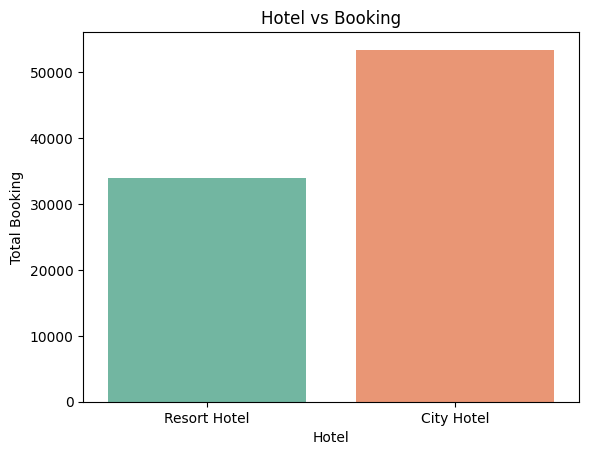

In [50]:
# the distribution of bookings by hotel type, month, and market segment
sns.countplot(data=df,
              x=df["hotel"],
              palette="Set2",
             hue=df["hotel"])
plt.title("Hotel vs Booking")
plt.xlabel("Hotel")
plt.ylabel("Total Booking")
plt.savefig("Hotel vs Booking.png")
plt.show()

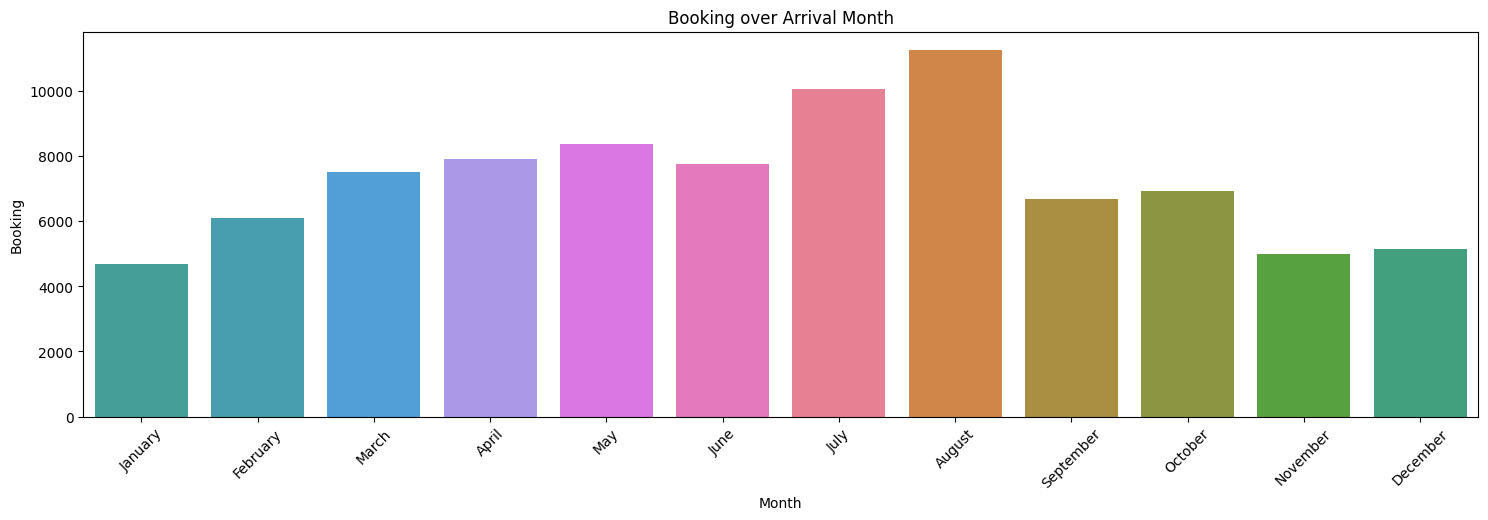

In [51]:
# the distribution of bookings by month
fig,axes = plt.subplots(figsize=(18,5))
month_order=['January', 'February', 'March', 'April', 'May', 'June','July', 'August', 'September', 'October', 'November', 'December']
sns.countplot(data=df,
             x=df["arrival_date_month"],order=month_order, hue=df["arrival_date_month"],
             orient="x")
plt.title("Booking over Arrival Month")
plt.xlabel("Month")
plt.ylabel("Booking")
plt.tick_params(axis='x', rotation=45)
plt.savefig("Booking over Arrival Month.png")
plt.show()

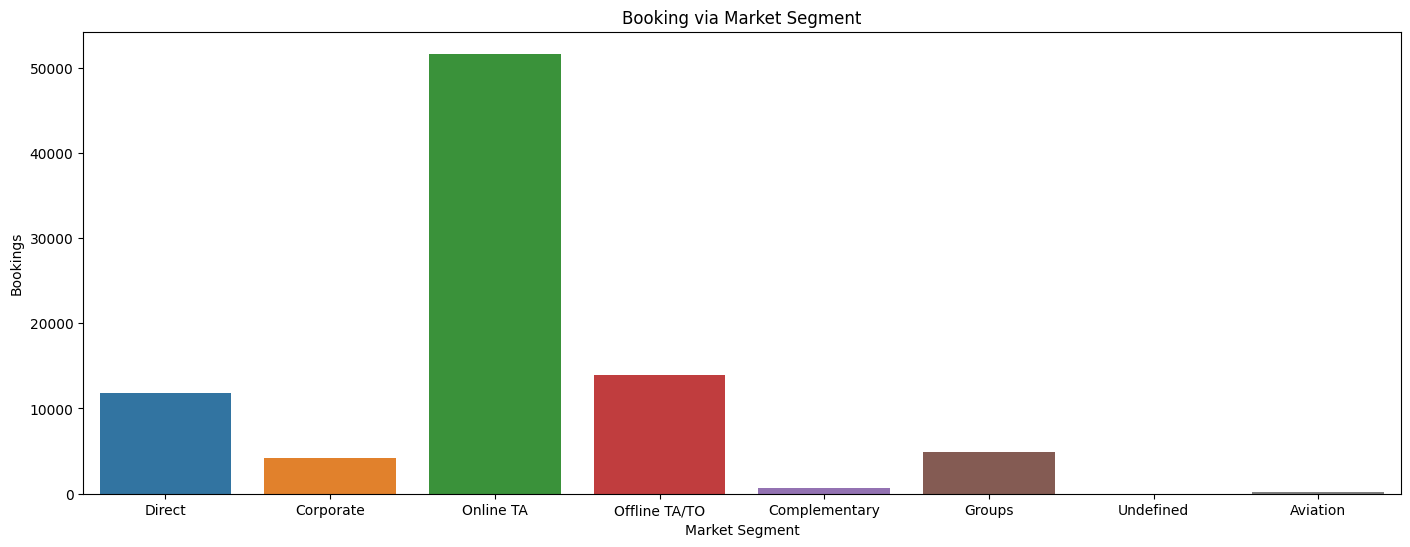

In [52]:
# Distribution by Market Segment
fig, axes = plt.subplots(figsize=(17,6))
sns.countplot(data=df,x="market_segment",hue='market_segment',legend=False)
plt.title("Booking via Market Segment")
plt.xlabel("Market Segment")
plt.ylabel("Bookings")

plt.savefig("Booking via Market Segment.png", bbox_inches="tight", dpi=300)
plt.show()

In [53]:
print(df["hotel"].value_counts())
print("\n",df["market_segment"].value_counts())

hotel
City Hotel      53428
Resort Hotel    33968
Name: count, dtype: int64

 market_segment
Online TA        51618
Offline TA/TO    13889
Direct           11804
Groups            4942
Corporate         4212
Complementary      702
Aviation           227
Undefined            2
Name: count, dtype: int64


## Basic Level Questions 

In [54]:
# Calculate the mean (average) of the 'lead_time' column.
avg_lead_time = df["lead_time"].mean().round(2)
print(f"Average Lead Time: {avg_lead_time :.2f} days")

Average Lead Time: 79.89 days


In [55]:
# How many bookings were canceled?
df["is_canceled"].value_counts()

is_canceled
0    63371
1    24025
Name: count, dtype: int64

In [56]:
# The most common arrival month for bookings?
most_common_arrival_month=df["arrival_date_month"].mode()[0]
print(f"The most common arrival month for bookings {most_common_arrival_month}.")

The most common arrival month for bookings August.


In [57]:
#What is the average number of special requests per booking?
df["total_of_special_requests"].mean()

np.float64(0.6985674401574443)

In [58]:
# country with the highest number of bookings
df["country"].mode()[0]

'PRT'

In [59]:
#What is the average daily rate (ADR) for each hotel type?
adr_hotel=df.groupby("hotel")["adr"].mean().round(2).reset_index()
print(f"average daily rate (ADR) for each hotel type {adr_hotel}")

average daily rate (ADR) for each hotel type           hotel     adr
0    City Hotel  110.99
1  Resort Hotel   99.03


In [60]:
#percentage of guests required car parking spaces?
parking_percentage=(df["required_car_parking_spaces"]>0).mean() * 100
print(f"Percentage of guests requiring parking : {parking_percentage}")

Percentage of guests requiring parking : 8.367659847132591


In [61]:
#the average stay duration in week nights and weekend nights?
week_nights_avg=df["stays_in_week_nights"].mean().round(2)
weekend_nights_avg=df["stays_in_weekend_nights"].mean().round(2)

print(f"The average stay duration in week nights is {week_nights_avg } and for weekend nights is {weekend_nights_avg}")

The average stay duration in week nights is 2.63 and for weekend nights is 1.01


In [62]:
#How many bookings were made through travel agents?
agent_booking=(df["agent"]>0).sum()
totalbooking=df["agent"].count()
print(f"bookings were made through travel agents: {(agent_booking/totalbooking)*100}")

bookings were made through travel agents: 86.04856057485468


## Medium Questions

In [63]:
# What is the cancellation rate for each hotel type?
canc_rate=df.groupby("hotel")["is_canceled"].mean()*100
canc_rate

hotel
City Hotel      30.038557
Resort Hotel    23.480923
Name: is_canceled, dtype: float64

  market_segment         adr
0      Online TA  118.171606
1         Direct  116.579429
2       Aviation  100.170396
3  Offline TA/TO   81.764191
4         Groups   74.864284
5      Corporate   68.151246
6      Undefined   15.000000
7  Complementary    3.049245


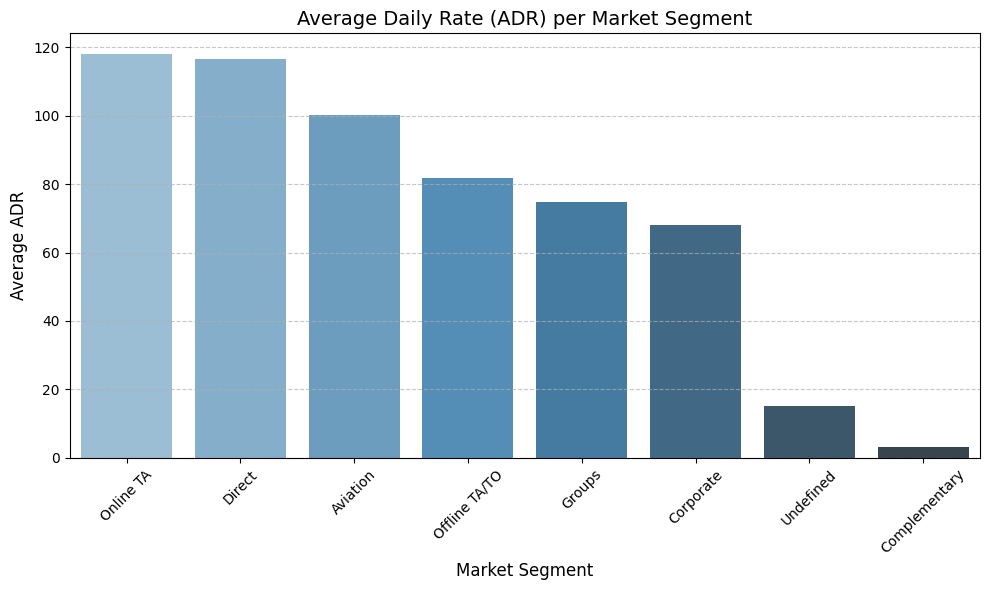

In [64]:
# 1. Calculate and sort the average ADR per market segment, then reset index
adr_market = df.groupby("market_segment")["adr"].mean().sort_values(ascending=False).reset_index()
print(adr_market)

# 2. Plot using the cleaned DataFrame
plt.figure(figsize=(10, 6))
sns.barplot(data=adr_market, x="market_segment", y="adr",hue="market_segment", palette="Blues_d")
plt.title("Average Daily Rate (ADR) per Market Segment", fontsize=14)
plt.xlabel("Market Segment", fontsize=12)
plt.ylabel("Average ADR", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig("Average Daily Rate (ADR) per Market Segment.png", bbox_inches="tight", dpi=300)
plt.tight_layout()
plt.show()

Corelation b/t lead_time and cancellation rate is : 0.185


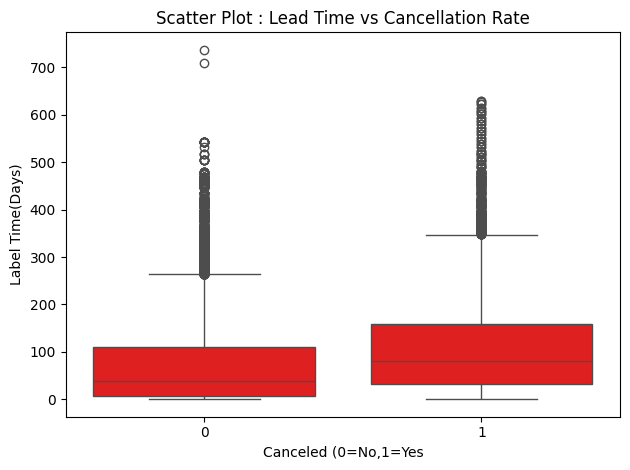

In [65]:
#3: What is the relationship between lead time and cancellation rate?
# whenever two elements are involved for relation use Scatterplot , boxplot. 
corr=df["lead_time"].corr(df["is_canceled"])
print(f"Corelation b/t lead_time and cancellation rate is : {corr:.3f}")

sns.boxplot(data=df,y="lead_time",x="is_canceled",color="red")
plt.title("Scatter Plot : Lead Time vs Cancellation Rate")
plt.ylabel("Label Time(Days)")
plt.xlabel("Canceled (0=No,1=Yes")
plt.tight_layout()
plt.savefig("Scatter Plot : Lead Time vs Cancellation Rate.png", bbox_inches="tight", dpi=300)
plt.show()

In [66]:
# Which distribution channel has the highest number of bookings?
df["distribution_channel"].value_counts().head(1)

distribution_channel
TA/TO    69141
Name: count, dtype: int64

In [67]:
# What is the average number of previous cancellations by hotel type?
canc_by_hotel=(df.groupby(["hotel"])["previous_cancellations"].mean()*100).round(2)
print(f"the average number of previous cancellations by hotel type :{canc_by_hotel}%")

the average number of previous cancellations by hotel type :hotel
City Hotel      3.58
Resort Hotel    2.20
Name: previous_cancellations, dtype: float64%


   arrival_date_year         adr
0               2015   92.160752
1               2016  101.538903
2               2017  118.710660


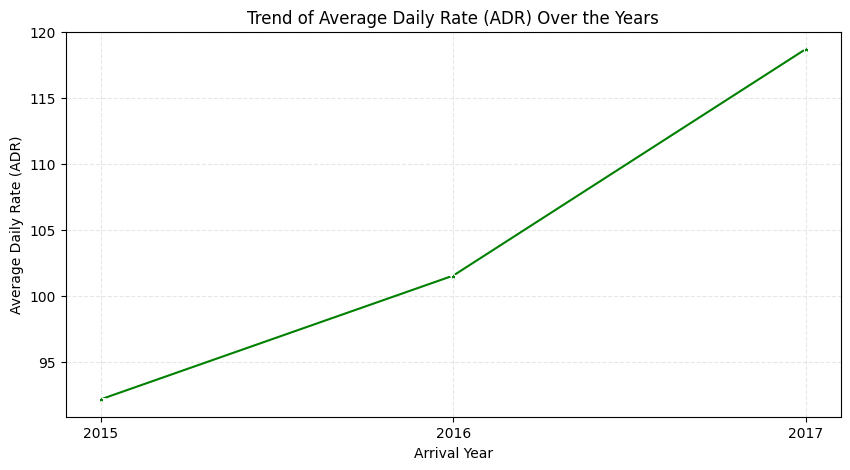

In [68]:
# Calculate the average ADR per year
ADR_trend=df.groupby("arrival_date_year")["adr"].mean().reset_index()
print(ADR_trend)
plt.figure(figsize=(10, 5))

sns.lineplot(data=ADR_trend,
    x="arrival_date_year",
    y="adr",
    marker="*",
    color="green")
plt.title('Trend of Average Daily Rate (ADR) Over the Years')
plt.xlabel('Arrival Year')
plt.ylabel('Average Daily Rate (ADR)')
plt.xticks(ADR_trend['arrival_date_year']) # Ensure only whole years are displayed
plt.grid(True, linestyle='--', alpha=0.3)
plt.savefig("Trend of Average Daily Rate (ADR) Over the Years.png", bbox_inches="tight", dpi=300)
plt.show()

In [69]:
# Which month has the highest revenue?
# revenue per month
rpm=df.groupby("arrival_date_month")["adr"].mean().sort_values(ascending=False).head(1)
rpm

arrival_date_month
August    150.87612
Name: adr, dtype: float64

In [70]:
# What is the impact of special requests on ADR?
correlation=df["total_of_special_requests"].corr(df["adr"])
correlation

#plot

np.float64(0.13783120378843688)

>  Weak linear relation b/w special_request and ADR

In [71]:
# What is the average stay duration for repeated guests versus new guests?

# first total stay duration
df["total_stay"]=df["stays_in_weekend_nights"]+df["stays_in_week_nights"]

# basically avg per is_repeated_guest column
avg_stay=df.groupby("is_repeated_guest")["total_stay"].mean()
avg_stay

is_repeated_guest
0    3.699932
1    1.927086
Name: total_stay, dtype: float64

In [72]:
# Which room type has the highest number of bookings?
df["reserved_room_type"].mode()

0    A
Name: reserved_room_type, dtype: object

## Advanced Questions

In [73]:
#1 What factors significantly impact the cancelation rate?
# Target_Col= is_linear()
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# 1. Define features (X) and target (y)
features = ["lead_time", "booking_changes", "total_of_special_requests"]
X = df[features].dropna()
y = df.loc[X.index, "is_canceled"]

# 2. Initialize and train the Logistic Regression model
model = LogisticRegression()
model.fit(X, y)

# 3. View the coefficients to see the impact of each feature
coefficients = dict(zip(features, model.coef_[0]))
for feature, coef in coefficients.items():
    print(f"{feature}: coefficient = {coef:.4f}")

lead_time: coefficient = 0.0050
booking_changes: coefficient = -0.4943
total_of_special_requests: coefficient = -0.3852


In [74]:
# 2 How does the ADR vary with the number of adults, children, and babies?
# Using Multivariate Analysis 
import statsmodels.api as sm

# 1. Define features (X) and target (y)
features = ["adults", "children", "babies"]
X = df[features].dropna()
y = df.loc[X.index, "adr"]

# 2. Add a constant to the model (for the intercept)
X_sm = sm.add_constant(X)

# 3. Fit the Ordinary Least Squares (OLS) regression model
model = sm.OLS(y, X_sm).fit()

# 4. Print the regression summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    adr   R-squared:                       0.165
Model:                            OLS   Adj. R-squared:                  0.165
Method:                 Least Squares   F-statistic:                     5752.
Date:                Mon, 28 Sep 2026   Prob (F-statistic):               0.00
Time:                        10:55:56   Log-Likelihood:            -4.6638e+05
No. Observations:               87396   AIC:                         9.328e+05
Df Residuals:                   87392   BIC:                         9.328e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         61.1803      0.538    113.647      0.0

In [75]:
# 3 What is the impact of booking changes on guest satisfaction as indicated by special requests?
correlation = df["booking_changes"].corr(df["total_of_special_requests"])
print(f"Correlation between booking changes and special requests: {correlation:.4f}")

Correlation between booking changes and special requests: 0.0161


In [76]:
#4 What is the seasonal impact on booking cancellations?
import calendar

# Create a chronological list of month names
month_order = list(calendar.month_name)[1:]

# Calculate the cancellation rate percentage for each month
monthly_cancellation = df.groupby("arrival_date_month")["is_canceled"].mean().reindex(month_order).reset_index()
monthly_cancellation.columns = ["arrival_date_month", "cancellation_rate"]
monthly_cancellation["cancellation_rate"] *= 100

print(monthly_cancellation)

   arrival_date_month  cancellation_rate
0             January          22.118048
1            February          23.204329
2               March          24.357780
3               April          30.462822
4                 May          29.228007
5                June          30.315518
6                July          31.798747
7              August          32.184419
8           September          24.544096
9             October          23.680415
10           November          21.101101
11           December          26.856363


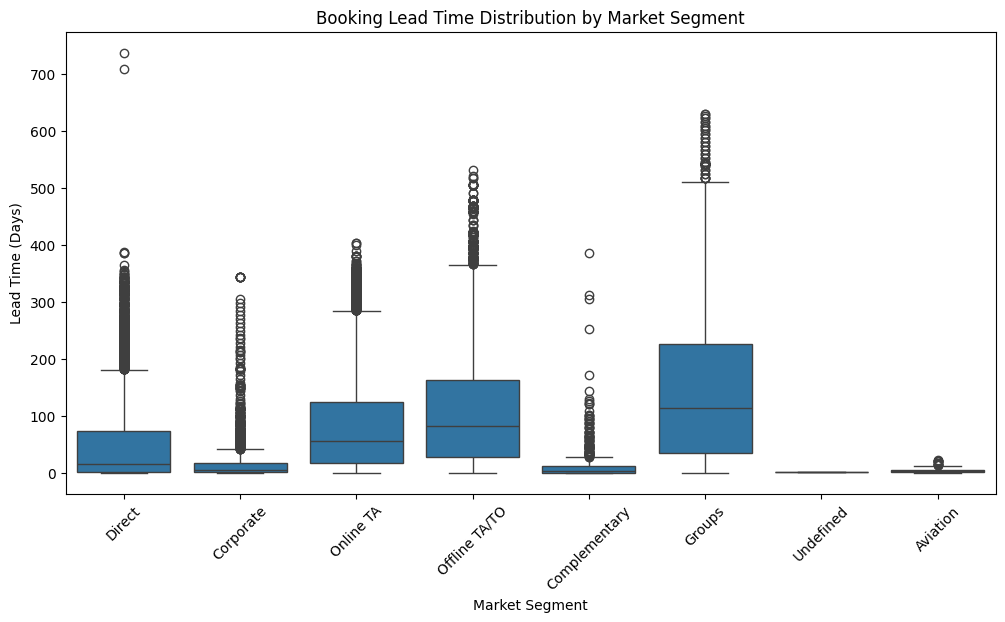

In [77]:
# 5: How does the booking lead time distribution vary between different market segments?
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="market_segment", y="lead_time")
plt.title("Booking Lead Time Distribution by Market Segment")
plt.xlabel("Market Segment")
plt.ylabel("Lead Time (Days)")
plt.xticks(rotation=45)
plt.savefig("Booking Lead Time Distribution by Market Segment.png", bbox_inches="tight", dpi=300)
plt.show()

In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 87396 entries, 0 to 119389
Data columns (total 34 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   hotel                           87396 non-null  object        
 1   is_canceled                     87396 non-null  int64         
 2   lead_time                       87396 non-null  int64         
 3   arrival_date_year               87396 non-null  int64         
 4   arrival_date_month              87396 non-null  object        
 5   arrival_date_week_number        87396 non-null  int64         
 6   arrival_date_day_of_month       87396 non-null  int64         
 7   stays_in_weekend_nights         87396 non-null  int64         
 8   stays_in_week_nights            87396 non-null  int64         
 9   adults                          87396 non-null  int64         
 10  children                        87396 non-null  float64       
 11  babies